## **Step 1: Load and describe the Wikipedia Vote Network**

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import urllib.request
import gzip
import io
import random
import numpy as np

# Reproducibility
random.seed(1)
np.random.seed(1)

# download directly from SNAP
url = "https://snap.stanford.edu/data/wiki-Vote.txt.gz"

# Download the gzipped file from the URL
response = urllib.request.urlopen(url)
compressed_file = io.BytesIO(response.read())

# Compress the file and read as text
with gzip.open(compressed_file, 'rt') as f:
    G_wiki = nx.read_edgelist(f, create_using=nx.DiGraph(), # directed graph
                              comments="#" # skip comment lines
                             )

# basic info
print(f"Number of nodes: {G_wiki.number_of_nodes()}")
print(f"Number of edges: {G_wiki.number_of_edges()}")
print(f"Is directed: {G_wiki.is_directed()}")

# check connectivity, because separate networks can affect the community detection
print(f"Is weakly connected: {nx.is_weakly_connected(G_wiki)}")
print(f"Number of weakly connected components: {nx.number_weakly_connected_components(G_wiki)}")
print(f"Is strongly connected: {nx.is_strongly_connected(G_wiki)}")
print(f"Number of strongly connected components: {nx.number_strongly_connected_components(G_wiki)}")

Number of nodes: 7115
Number of edges: 103689
Is directed: True
Is weakly connected: False
Number of weakly connected components: 24
Is strongly connected: False
Number of strongly connected components: 5816


In [ ]:
# find the largest weakly connected component
largest_weakly_connected_component = max(nx.weakly_connected_components(G_wiki), key=len)

# create subgraph with only largest component
G_wiki_subgraph = G_wiki.subgraph(largest_weakly_connected_component).copy()

print(f"Number of nodes in largest weakly connected component: {G_wiki_subgraph.number_of_nodes()}")
print(f"Number of edges in largest weakly connected component: {G_wiki_subgraph.number_of_edges()}")
print(f"Percentage of original network: {G_wiki_subgraph.number_of_nodes() / G_wiki.number_of_nodes() * 100:.1f}%")

Number of nodes in largest weakly connected component: 7066
Number of edges in largest weakly connected component: 103663
Percentage of original network: 99.3%


In [ ]:
# find the largest strongly connected component
largest_scc = max(nx.strongly_connected_components(G_wiki),
                  key=len)

# create subgraph with only the largest strong component
G_wiki_subgraph_strong = G_wiki.subgraph(largest_scc).copy()

print(f"Largest strongly connected component nodes: {G_wiki_subgraph_strong.number_of_nodes()}")
print(f"Largest strongly connected component edges: {G_wiki_subgraph_strong.number_of_edges()}")
print(f"Percentage of original network: {G_wiki_subgraph_strong.number_of_nodes()/G_wiki.number_of_nodes()*100:.1f}%")

Largest strongly connected component nodes: 1300
Largest strongly connected component edges: 39456
Percentage of original network: 18.3%


## **Step 2: Degree Analysis**

In [ ]:
# in-degree and out-degree on subgraph component
in_degrees = dict(G_wiki_subgraph.in_degree())
out_degrees = dict(G_wiki_subgraph.out_degree())

# highest in-degree (most voted for)
sorted_in_degrees = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)

print("Top 5 most voted for:")
for node, degree in sorted_in_degrees[:5]:
    print(f"Node {node} has {degree} in-degrees")

# highest out-degree (most active voters)
sorted_out_degrees = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)

print("Top 5 most active voters:")
for node, degree in sorted_out_degrees[:5]:
    print(f"Node {node} has {degree} out-degrees")

# average degrees
print(f"Average in-degree: {sum(in_degrees.values()) / G_wiki_subgraph.number_of_nodes():2f}")
print(f"Average out-degree: {sum(out_degrees.values()) / G_wiki_subgraph.number_of_nodes():2f}")



Top 5 most voted for:
Node 4037 has 457 in-degrees
Node 15 has 361 in-degrees
Node 2398 has 340 in-degrees
Node 2625 has 331 in-degrees
Node 1297 has 309 in-degrees
Top 5 most active voters:
Node 2565 has 893 out-degrees
Node 766 has 773 out-degrees
Node 11 has 743 out-degrees
Node 457 has 732 out-degrees
Node 2688 has 618 out-degrees
Average in-degree: 14.670676
Average out-degree: 14.670676


## **Step 3: Degree distribution plots**

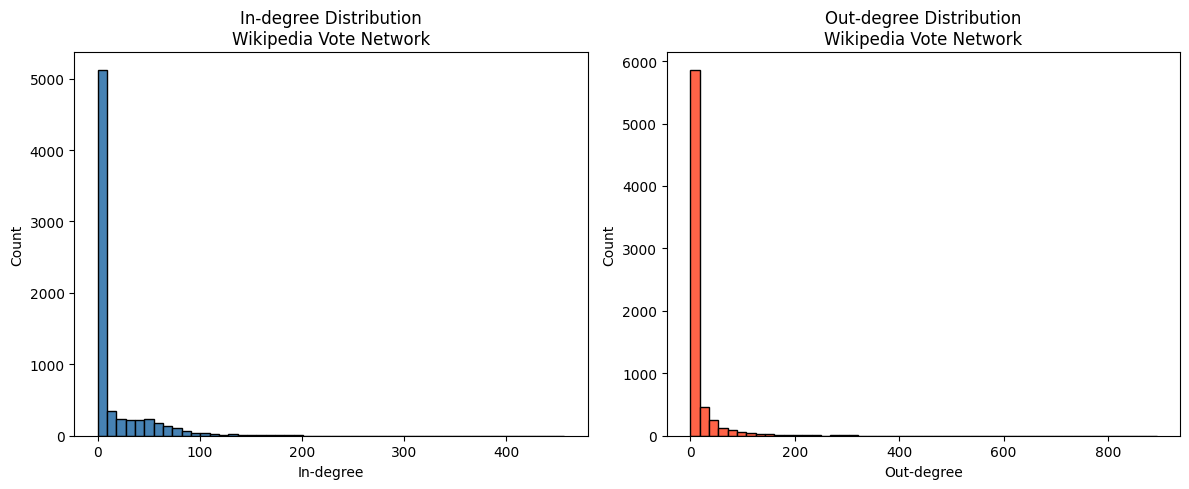

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # pattern of 2 plots

# in-degree distribution
in_degree_values = list(in_degrees.values())
axes[0].hist(in_degree_values, bins=50,
             color="steelblue", edgecolor="black")
axes[0].set_title("In-degree Distribution\nWikipedia Vote Network")
axes[0].set_xlabel("In-degree")
axes[0].set_ylabel("Count")

# out-degree distribution
out_deg_values = list(out_degrees.values())
axes[1].hist(out_deg_values, bins=50,
             color="tomato", edgecolor="black")
axes[1].set_title("Out-degree Distribution\nWikipedia Vote Network")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Count")

# visualize
plt.tight_layout()
plt.show()

## **Step 4: Community Detection**

In [ ]:
from cdlib import algorithms, evaluation
# create an undirected copy because Louvain and Walktrap require undirected graphs
G_wiki_undirected = G_wiki_subgraph.to_undirected()

# verify
print(f"Directed version - Is directed: {G_wiki_subgraph.is_directed()}")
print(f"Undirected version - Is directed: {G_wiki_undirected.is_directed()}")

# run three methods on the subgraph weak component
louvain_wiki = algorithms.louvain(G_wiki_undirected)
infomap_wiki = algorithms.infomap(G_wiki_subgraph)
walktrap_wiki = algorithms.walktrap(G_wiki_undirected)

# print number of communities found
print(f"\nLouvain: {len(louvain_wiki.communities)} communities found")
print(f"Infomap: {len(infomap_wiki.communities)} communities found")
print(f"Walktrap: {len(walktrap_wiki.communities)} communities found")

Directed version - Is directed: True
Undirected version - Is directed: False

Louvain: 11 communities found
Infomap: 74 communities found
Walktrap: 2339 communities found


## **Step 5: Change the Walktrap with Leiden**

In [ ]:

leiden_wiki = algorithms.leiden(G_wiki_undirected)

print(f"Leiden: {len(leiden_wiki.communities)} communities found")

Leiden: 16 communities found


## **Step 6: Check the community sizes**

In [ ]:
from cdlib import algorithms, evaluation


label_wiki = algorithms.label_propagation(G_wiki_undirected)

for name, method in [("Louvain", louvain_wiki),
                   ("Infomap", infomap_wiki),
                   ("Leiden", leiden_wiki)]:
    sizes = sorted([len(community) for community in method.communities],
            reverse=True)

    print(f"{name}:")
    print(f"Number of communities: {len(sizes)}")
    print(f"Largest community size: {sizes[0]}")
    print(f"Smallest community size: {sizes[-1]}")
    print(f"Average community size: {sum(sizes) / len(sizes):.1f}")

Louvain:
Number of communities: 11
Largest community size: 2299
Smallest community size: 2
Average community size: 642.4
Infomap:
Number of communities: 74
Largest community size: 2850
Smallest community size: 2
Average community size: 95.5
Leiden:
Number of communities: 16
Largest community size: 2666
Smallest community size: 2
Average community size: 441.6


In [ ]:
import networkx.algorithms.community as nx_comm

# compute modularity for each method
# we need to convert communities to sets first
louvain_sets = [set(c) for c in louvain_wiki.communities]
leiden_sets  = [set(c) for c in leiden_wiki.communities]
infomap_sets = [set(c) for c in infomap_wiki.communities]

# modularity works on undirected graphs
mod_louvain = nx_comm.modularity(G_wiki_undirected, louvain_sets)
mod_leiden  = nx_comm.modularity(G_wiki_undirected, leiden_sets)
mod_infomap = nx_comm.modularity(G_wiki_undirected, infomap_sets)

print(f"Modularity Louvain:  {mod_louvain:.4f}")
print(f"Modularity Leiden:   {mod_leiden:.4f}")
print(f"Modularity Infomap:  {mod_infomap:.4f}")

Modularity Louvain:  0.4182
Modularity Leiden:   0.4182
Modularity Infomap:  0.4129


## **Step 7: Visualization**

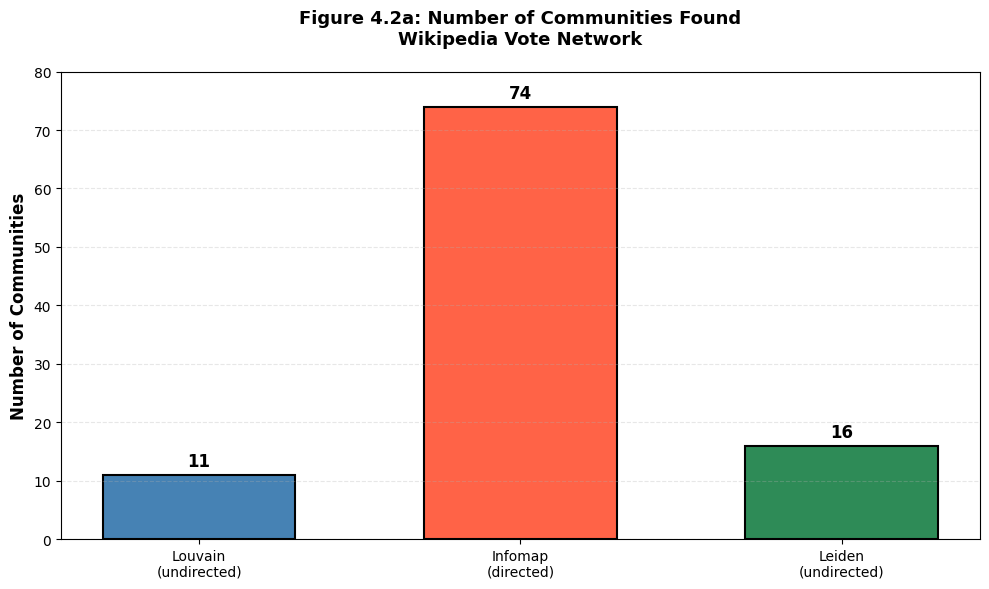

Figure 4.2a saved as 'figure_4_2a_wikipedia_communities.png'


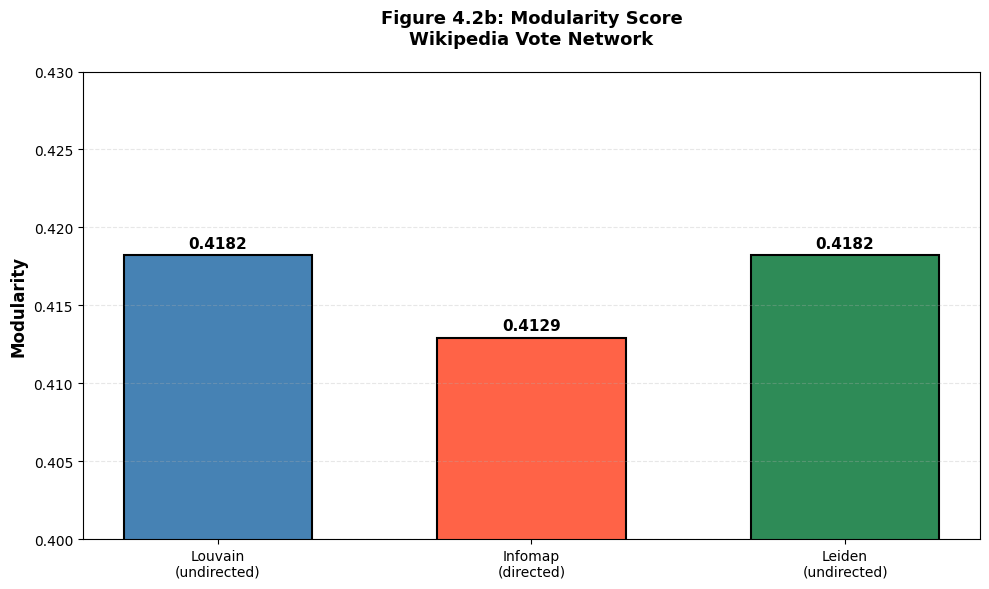

Figure 4.2 saved as 'figure_4_2_wikipedia_modularities.png'


In [ ]:
import matplotlib.pyplot as plt

methods = ["Louvain\n(undirected)",
           "Infomap\n(directed)",
           "Leiden\n(undirected)"]

communities = [11, 74, 16]  # Communities data
modularities = [0.4182, 0.4129, 0.4182]  # Modularities data


# FIGURE 4.2a: Number of Communities Found

fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(methods, communities,
        color=["steelblue", "tomato", "seagreen"],
        edgecolor="black", linewidth=1.5, width=0.6)

ax1.set_title("Figure 4.2a: Number of Communities Found\nWikipedia Vote Network",
              fontsize=13, fontweight="bold", pad=20)
ax1.set_ylabel("Number of Communities", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 80)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(communities):
    ax1.text(i, v + 1.5, str(v),
             ha="center", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig('/content/figure_4_2a_wikipedia_communities.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.2a saved as 'figure_4_2a_wikipedia_communities.png'")


# FIGURE 4.2b: Modularity Score

fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.bar(methods, modularities,
        color=["steelblue", "tomato", "seagreen"],
        edgecolor="black", linewidth=1.5, width=0.6)

ax2.set_title("Figure 4.2b: Modularity Score\nWikipedia Vote Network",
              fontsize=13, fontweight="bold", pad=20)
ax2.set_ylabel("Modularity", fontsize=12, fontweight="bold")
ax2.set_ylim(0.40, 0.43)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(modularities):
    ax2.text(i, v + 0.0005, f"{v:.4f}",
             ha="center", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig('/content/figure_4_2_wikipedia_modularities.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure 4.2 saved as 'figure_4_2_wikipedia_modularities.png'")